# Real-Time Fact-Checking & Media Bias Analyzer — Hybrid RAG on FEVER

**Pipeline:** Claim → Hybrid Retrieval (Dense + BM25) → Cross-Encoder Reranking → NLI Verification → Verdict (Supports / Refutes / Not Enough Info) → Evidence Sentiment Signal

This notebook builds and evaluates an end-to-end fact-checking system on the [FEVER](https://fever.ai/) dataset:

1. **Data preparation & EDA** — load FEVER, inspect label balance, claim length, evidence structure.
2. **Knowledge base** — Simple English Wikipedia passages as the evidence corpus.
3. **Hybrid retrieval** — dense (SentenceTransformer + FAISS) combined with sparse (BM25) retrieval.
4. **Reranking** — a cross-encoder reorders the merged candidate pool for precision.
5. **Verification** — a FEVER-tuned NLI model classifies claim vs. evidence, with a confidence gate.
6. **Evaluation** — retrieval Recall@k and end-to-end accuracy / F1 / confusion matrix / latency.
7. **Evidence sentiment signal** — a lightweight, clearly-scoped bias/sentiment prototype on retrieved evidence.

> **Note on a design change from earlier drafts:** the original knowledge base relied on `Cohere/wikipedia-22-12-simple-embeddings`, which turned out to be a dependency on shaky ground twice over — its embeddings came from Cohere's `multilingual-22-12` model, which Cohere has since retired, and separately the dataset itself is now gated/inaccessible on the Hub. This notebook instead builds its own passage corpus locally from `wikimedia/wikipedia` (public, Wikimedia-maintained) and embeds it with a local SentenceTransformer model — no external API dependency, no risk of a third party pulling access, and claims/documents guaranteed to share one embedding space.

## 1. Setup

In [1]:
!pip install --quiet faiss-cpu sentence-transformers rank_bm25 wordcloud vaderSentiment sentencepiece datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 67.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.8 MB/s eta 0:00:00


In [2]:
import os
import re
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import gc
from tqdm import tqdm
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import faiss
from datasets import load_dataset
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

### Configuration

Central place for every model name, retrieval width, and threshold used later in the notebook — makes the pipeline easy to re-tune without hunting through cells.

In [3]:
SEED = 42
np.random.seed(SEED)

# Model checkpoints
EMBED_MODEL_NAME     = "sentence-transformers/all-MiniLM-L6-v2"
RERANKER_MODEL_NAME  = "cross-encoder/ms-marco-MiniLM-L-6-v2"
# NLI_MODEL_NAME       = "MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli"
NLI_MODEL_NAME = "ynie/roberta-large-snli_mnli_fever_anli_R1_R2_R3-nli"

# Retrieval widths
K_DENSE   = 50   # candidates pulled from the dense FAISS index
K_BM25    = 50   # candidates pulled from BM25
K_HYBRID  = 20   # merged candidate pool size passed to the reranker
K_FINAL   = 8    # top reranked passages passed to the NLI model

# Decision logic
CONF_THRESHOLD = 0.55   # SUPPORTS/REFUTES below this confidence fall back to NOT ENOUGH INFO

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 2. Load FEVER Data

In [4]:
def load_jsonl_auto(path):
    if path.endswith(".gz"):
        import gzip
        with gzip.open(path, "rt", encoding="utf-8") as f:
            return [json.loads(line) for line in f]
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train_path = "/kaggle/input/datasets/suchintikasarkar/factlover-dataset/train.jsonl"
dev_path   = "/kaggle/input/datasets/suchintikasarkar/factlover-dataset/shared_task_dev.jsonl"
test_path  = "/kaggle/input/datasets/suchintikasarkar/fever-data-test/shared_task_test.jsonl"

fever_train = pd.DataFrame(load_jsonl_auto(train_path))
fever_dev   = pd.DataFrame(load_jsonl_auto(dev_path))
fever_test  = pd.DataFrame(load_jsonl_auto(test_path))

display(fever_train.head())
print("Train:", fever_train.shape)
print("Dev:  ", fever_dev.shape)
print("Test: ", fever_test.shape)

,id,verifiable,label,claim,evidence
0,75397,VERIFIABLE,SUPPORTS,Nikolaj Coster-Waldau worked with the Fox Broa...,"[[[92206, 104971, Nikolaj_Coster-Waldau, 7], [..."
1,150448,VERIFIABLE,SUPPORTS,Roman Atwood is a content creator.,"[[[174271, 187498, Roman_Atwood, 1]], [[174271..."
2,214861,VERIFIABLE,SUPPORTS,"History of art includes architecture, dance, s...","[[[255136, 254645, History_of_art, 2]]]"
3,156709,VERIFIABLE,REFUTES,Adrienne Bailon is an accountant.,"[[[180804, 193183, Adrienne_Bailon, 0]]]"
4,83235,NOT VERIFIABLE,NOT ENOUGH INFO,System of a Down briefly disbanded in limbo.,"[[[100277, None, None, None]]]"


Train: (145449, 5)
Dev:   (19998, 5)
Test:  (19998, 2)


In [5]:
import os

print(os.getcwd())
print(os.listdir("/kaggle"))
print(os.listdir("/kaggle/input"))

/kaggle/working
['lib', 'input', 'working']
['datasets']


### Extract gold evidence page titles

Used both for EDA (evidence-count distribution) and later for retrieval-quality evaluation (Recall@k).

In [6]:
def extract_evidence_titles(row):
    titles = set()
    ev = row.get("evidence", [])
    if not isinstance(ev, list):
        return titles
    for ev_group in ev:
        if isinstance(ev_group, list):
            for ev_item in ev_group:
                if isinstance(ev_item, list) and len(ev_item) >= 3:
                    title = ev_item[2]
                    if isinstance(title, str) and title not in ["None", "", " "]:
                        titles.add(title)
    return titles

all_titles = set()
for df in [fever_train, fever_dev, fever_test]:
    df["ev_titles"] = df.apply(extract_evidence_titles, axis=1)
    for t in df["ev_titles"]:
        all_titles.update(t)

print("Unique FEVER evidence titles across all splits:", len(all_titles))

Unique FEVER evidence titles across all splits: 14533


## 3. Exploratory Data Analysis

A quick look at label balance, claim length, and evidence structure before building anything on top of the data.

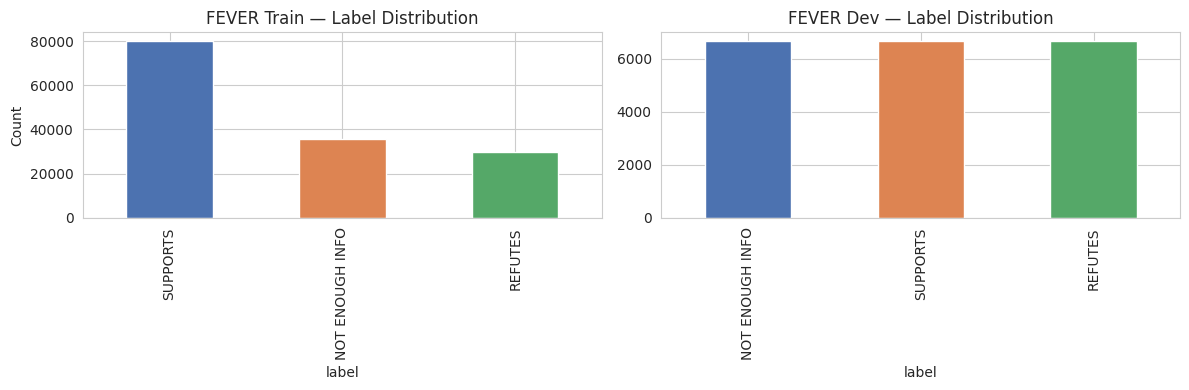

verifiable
VERIFIABLE        109810
NOT VERIFIABLE     35639
Name: count, dtype: int64


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fever_train["label"].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#DD8452", "#55A868"])
ax[0].set_title("FEVER Train — Label Distribution")
ax[0].set_ylabel("Count")

fever_dev["label"].value_counts().plot(kind="bar", ax=ax[1], color=["#4C72B0", "#DD8452", "#55A868"])
ax[1].set_title("FEVER Dev — Label Distribution")
plt.tight_layout()
plt.show()

print(fever_train["verifiable"].value_counts())

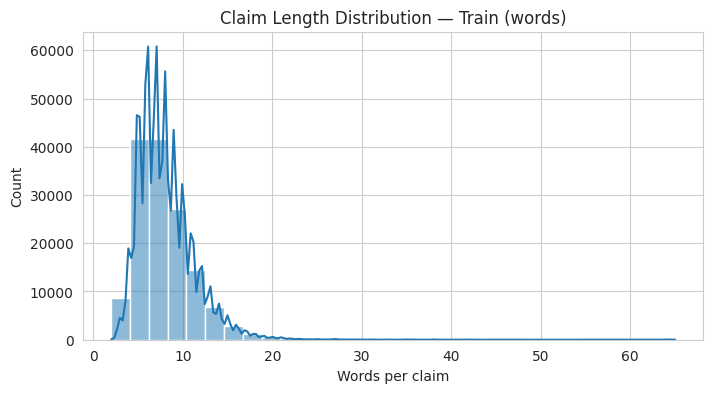

count    145449.000000
mean          8.101389
std           3.205078
min           2.000000
25%           6.000000
50%           8.000000
75%          10.000000
max          65.000000
Name: claim, dtype: float64


In [8]:
claim_lengths = fever_train["claim"].str.split().apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(claim_lengths, bins=30, kde=True)
plt.title("Claim Length Distribution — Train (words)")
plt.xlabel("Words per claim")
plt.show()

print(claim_lengths.describe())

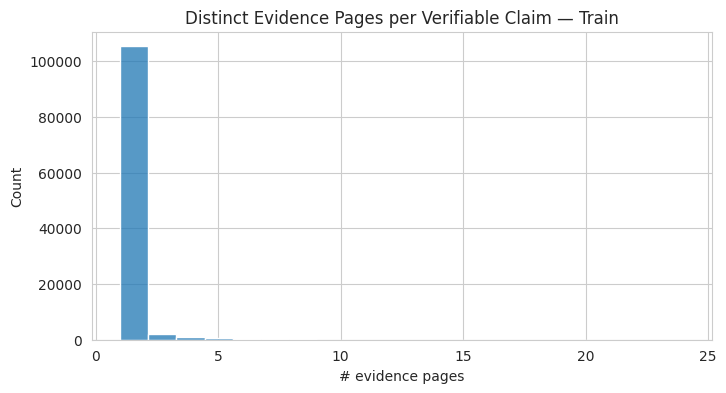

In [9]:
evidence_counts = fever_train["ev_titles"].apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(evidence_counts[evidence_counts > 0], bins=20)
plt.title("Distinct Evidence Pages per Verifiable Claim — Train")
plt.xlabel("# evidence pages")
plt.show()

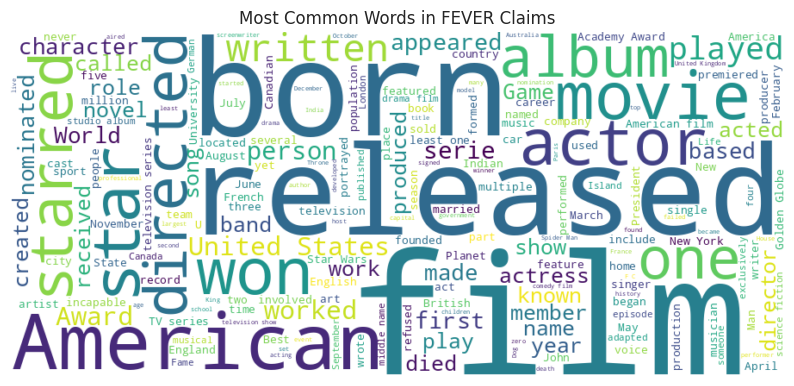

In [10]:
sample_text = " ".join(fever_train["claim"].sample(20000, random_state=SEED).astype(str))
wc = WordCloud(width=900, height=400, background_color="white", colormap="viridis").generate(sample_text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in FEVER Claims")
plt.show()

## 4. Cleaning & Label Preparation

In [11]:
label_map = {"SUPPORTS": 2, "REFUTES": 1, "NOT ENOUGH INFO": 0}

def clean_claim_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"-LRB-|-RRB-", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def clean_fever_split(df):
    df = df.copy()
    df["claim_orig"]  = df["claim"]
    df["claim_clean"] = df["claim"].apply(clean_claim_text)
    df["label_id"]    = df["label"].map(label_map) if "label" in df else None
    return df

train_df = clean_fever_split(fever_train)
dev_df   = clean_fever_split(fever_dev)
test_df  = clean_fever_split(fever_test)

print("Verifiable counts in train:")
print(train_df["verifiable"].value_counts())

Verifiable counts in train:
verifiable
VERIFIABLE        109810
NOT VERIFIABLE     35639
Name: count, dtype: int64


## 5. Knowledge Base — Wikipedia Corpus

Full English Wikipedia (5.4M pages) exceeded Kaggle's memory/runtime budget when embedded end-to-end. Simple English Wikipedia is the scoped-down corpus used here.

**Second source change from the previous draft:** `Cohere/wikipedia-22-12-simple-embeddings` turned out to be gated/inaccessible (`401` on the Hub, `DatasetNotFoundError` from `load_dataset`) on top of shipping embeddings from a retired model — two independent reasons not to depend on it. This version builds the corpus instead from `wikimedia/wikipedia` (the `20231101.simple` config), which is public, unauthenticated, and maintained directly by the Wikimedia Foundation — a much safer long-term dependency than a third party's derived dataset.

That dataset ships **full articles**, not pre-chunked passages, so this section also does the chunking that earlier drafts skipped: each article is split into paragraph-sized passages (~120 words, dropping fragments under 8 words) before indexing. The result is cached to disk so this only runs once per session.

In [12]:
from datasets import Dataset

def chunk_text(text, max_words=120, min_words=8):
    paragraphs = [p.strip() for p in text.split("\n") if p.strip()]
    chunks = []
    for para in paragraphs:
        words = para.split()
        if not words:
            continue
        if len(words) <= max_words:
            if len(words) >= min_words:
                chunks.append(para)
        else:
            for i in range(0, len(words), max_words):
                piece = " ".join(words[i:i + max_words])
                if len(piece.split()) >= min_words:
                    chunks.append(piece)
    return chunks

WIKI_CACHE = Path("/kaggle/working/wiki_corpus.parquet")

if WIKI_CACHE.exists():
    print("Loading cached chunked corpus...")
    wiki_df = pd.read_parquet(WIKI_CACHE)
else:
    print("Loading Simple English Wikipedia and chunking into passages (one-time step)...")
    raw_wiki = load_dataset("wikimedia/wikipedia", "20231101.simple", split="train")

    records = []
    for row in tqdm(raw_wiki, total=len(raw_wiki)):
        for chunk in chunk_text(row["text"]):
            records.append({"title": row["title"], "text": chunk, "url": row["url"]})

    wiki_df = pd.DataFrame(records)
    wiki_df.to_parquet(WIKI_CACHE)

wiki = Dataset.from_pandas(wiki_df, preserve_index=False)
print(f"Knowledge base ready: {len(wiki)} passages from {wiki_df['title'].nunique()} articles")

Loading Simple English Wikipedia and chunking into passages (one-time step)...


README.md: 0.00B [00:00, ?B/s]

20231101.simple/train-00000-of-00001.par(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/241787 [00:00<?, ? examples/s]

100%|██████████| 241787/241787 [00:13<00:00, 17395.33it/s]


Knowledge base ready: 1199212 passages from 240399 articles


## 6. Dense Retrieval — Local Embeddings + FAISS

Encoding the corpus locally (instead of relying on a hosted embedding API) means claims and documents are guaranteed to share the same vector space, and the pipeline has no external API dependency at inference time. Embeddings are cached to disk so this only runs once per session.

In [13]:
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)

EMBED_CACHE = Path("/kaggle/working/wiki_embeddings.npy")

if EMBED_CACHE.exists():
    print("Loading cached corpus embeddings...")
    doc_embeddings = np.load(EMBED_CACHE)
else:
    print("Encoding Wikipedia corpus locally (one-time step)...")
    passages = [f"{t} {x}" for t, x in zip(wiki["title"], wiki["text"])]
    doc_embeddings = embed_model.encode(
        passages,
        batch_size=256,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")
    np.save(EMBED_CACHE, doc_embeddings)
    del passages
    gc.collect()

print("Embedding matrix shape:", doc_embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding Wikipedia corpus locally (one-time step)...


Batches:   0%|          | 0/4685 [00:00<?, ?it/s]

Embedding matrix shape: (1199212, 384)


In [14]:
EMBED_DIM = doc_embeddings.shape[1]

dense_index = faiss.IndexFlatIP(EMBED_DIM)   # vectors are already normalized -> inner product == cosine similarity
dense_index.add(doc_embeddings)

faiss.write_index(dense_index, "/kaggle/working/wiki_dense.index")
print(f"Dense FAISS index built: {dense_index.ntotal} vectors, dim={dense_index.d}")

def embed_query(text: str) -> np.ndarray:
    return embed_model.encode([text], convert_to_numpy=True, normalize_embeddings=True).astype("float32")

Dense FAISS index built: 1199212 vectors, dim=384


## 7. Sparse Retrieval — BM25

Dense retrieval alone tends to miss claims that hinge on exact names, numbers, or rare terms with little semantic paraphrasing. BM25 covers that gap; it is combined with the dense index in the next section.

In [15]:
def simple_tokenize(text):
    return re.findall(r"[a-z0-9]+", text.lower())

BM25_TOKENS_CACHE = Path("/kaggle/working/bm25_tokens.json")

if BM25_TOKENS_CACHE.exists():
    print("Loading cached BM25 tokens...")
    with open(BM25_TOKENS_CACHE) as f:
        tokenized_corpus = json.load(f)
else:
    print("Tokenizing corpus for BM25 (one-time step)...")
    tokenized_corpus = [
        simple_tokenize(f"{t} {x}")
        for t, x in tqdm(zip(wiki["title"], wiki["text"]), total=len(wiki))
    ]
    with open(BM25_TOKENS_CACHE, "w") as f:
        json.dump(tokenized_corpus, f)

bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index ready over", len(tokenized_corpus), "passages")

Tokenizing corpus for BM25 (one-time step)...


100%|██████████| 1199212/1199212 [00:49<00:00, 24110.61it/s]


BM25 index ready over 1199212 passages


## 8. Hybrid Retrieval

Merge dense and BM25 candidates by min-max normalizing each score list independently, then summing with equal weight. This is a simple, tunable alternative to the crude keyword-overlap filter used in an earlier draft — that filter dropped any claim whose words didn't literally appear in a page title, which silently capped recall on paraphrased claims.

In [16]:
def hybrid_retrieve(claim, k_dense=K_DENSE, k_bm25=K_BM25, top_k=K_HYBRID):
    q_emb = embed_query(claim)
    dense_scores, dense_idx = dense_index.search(q_emb, k_dense)
    dense_scores, dense_idx = dense_scores[0], dense_idx[0]

    bm25_scores_all = bm25.get_scores(simple_tokenize(claim))
    bm25_top_idx = np.argsort(bm25_scores_all)[::-1][:k_bm25]
    bm25_top_scores = bm25_scores_all[bm25_top_idx]

    candidates = {}

    if len(dense_scores):
        d_min, d_max = dense_scores.min(), dense_scores.max()
        for idx, s in zip(dense_idx, dense_scores):
            if idx == -1:
                continue
            norm_s = (s - d_min) / (d_max - d_min + 1e-9)
            candidates[int(idx)] = candidates.get(int(idx), 0.0) + 0.5 * norm_s

    if len(bm25_top_scores):
        b_min, b_max = bm25_top_scores.min(), bm25_top_scores.max()
        for idx, s in zip(bm25_top_idx, bm25_top_scores):
            norm_s = (s - b_min) / (b_max - b_min + 1e-9)
            candidates[int(idx)] = candidates.get(int(idx), 0.0) + 0.5 * norm_s

    ranked = sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:top_k]

    results = []
    for idx, score in ranked:
        row = wiki[idx]
        results.append({
            "title": row["title"],
            "text": row["text"],
            "url": row["url"],
            "hybrid_score": float(score),
        })
    return results

## 9. Cross-Encoder Reranking

The hybrid step optimizes for recall across a wide candidate pool; a cross-encoder then re-scores each (claim, passage) pair jointly for precision before the small, expensive NLI stage sees them.

In [17]:
reranker = CrossEncoder(RERANKER_MODEL_NAME, max_length=512, device=DEVICE)

def rerank(claim, candidates, top_k=K_FINAL):
    if not candidates:
        return candidates
    pairs = [(claim,  c["title"] + " " + c["text"]) for c in candidates]
    scores = reranker.predict(pairs)
    for c, s in zip(candidates, scores):
        c["rerank_score"] = float(s)
    return sorted(candidates, key=lambda x: x["rerank_score"], reverse=True)[:top_k]

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [18]:
claim = "Albert Einstein was a physicist"

candidates = hybrid_retrieve(
    claim,
    top_k=10
)

for i, c in enumerate(candidates):

    print("=" * 80)

    print(i + 1)

    print(c["title"])

    print(c["text"][:300])

1
1955
April 18 – Albert Einstein, German physicist (b. 1879)
2
Albert Einstein
He was awarded the Nobel Prize in Physics.
3
Renaissance man
Albert Einstein (14 March 1879 – 15 April 1955) was a German-American physicist, mathematician, cosmologist, professor, refrigeration engineer (patent), patent analyst, essayist, activist, pianist, and recital violinist.
4
Albert Einstein
Albert Einstein (14 March 1879 – 18 April 1955) was a German-born American scientist. He worked on theoretical physics. He developed the theory of relativity. He received the Nobel Prize in Physics in 1921 for theoretical physics.
5
April 18
1955 – Albert Einstein, German physicist and Nobel laureate (b. 1879)
6
March 14
1879 – Albert Einstein, German-born theoretical physicist, Nobel Prize laureate (d. 1955)
7
December 5
1932 – German physicist Albert Einstein granted a visa
8
April 18
1955 – World-famous physicist Albert Einstein dies aged 76.
9
Albert Einstein
Einstein, Albert and Infeld, Leopold 1938. The evo

## 10. Retrieval Evaluation — Recall@k

Measures whether the *correct* Wikipedia page is anywhere in the retrieved set, independent of the downstream NLI model. This isolates retrieval quality from verification quality — if Recall@k is low, no amount of NLI tuning can fix accuracy, since the model never sees the right evidence.

Reranking reorders this same candidate pool for precision but doesn't expand it, so Recall@k is measured on the hybrid pool directly.

In [19]:
# def retrieval_recall_at_k(df, k=5, sample_size=150, seed=SEED):
#     sample = df[df["verifiable"] == "VERIFIABLE"].sample(n=min(sample_size, len(df)), random_state=seed)
#     hits, total = 0, 0
#     for _, row in tqdm(sample.iterrows(), total=len(sample)):
#         gold_titles = row["ev_titles"]
#         if not gold_titles:
#             continue
#         candidates = hybrid_retrieve(row["claim_clean"], top_k=k)
#         retrieved_titles = {c["title"] for c in candidates}
#         if retrieved_titles & gold_titles:
#             hits += 1
#         total += 1
#     recall = hits / total if total else 0.0
#     print(f"Recall@{k}: {recall:.3f}  ({hits}/{total})")
#     return recall

# recall_at_5  = retrieval_recall_at_k(dev_df, k=5,  sample_size=150)
# recall_at_10 = retrieval_recall_at_k(dev_df, k=10, sample_size=150)

In [20]:
import re

def normalize_title(title):
    if title is None:
        return ""

    title = title.replace("_", " ")

    title = title.replace("-LRB-", "(")
    title = title.replace("-RRB-", ")")

    title = re.sub(r"\s+", " ", title)

    return title.strip().lower()
    
def retrieval_recall_at_k(
    df,
    k=5,
    sample_size=150,
    seed=42
):

    sample = (
        df[df["verifiable"]=="VERIFIABLE"]
        .sample(
            n=min(sample_size,len(df)),
            random_state=seed
        )
    )

    hits=0
    total=0
    skipped=0

    for _,row in tqdm(sample.iterrows(),total=len(sample)):

        gold={
            normalize_title(t)
            for t in row["ev_titles"]
        }

        if len(gold)==0:
            skipped+=1
            continue

        retrieved={
            normalize_title(c["title"])
            for c in hybrid_retrieve(
                row["claim"],
                top_k=k
            )
        }

        if retrieved & gold:
            hits+=1

        total+=1

    print(f"Hits     : {hits}")
    print(f"Total    : {total}")
    print(f"Skipped  : {skipped}")
    print(f"Recall@{k}: {hits/total:.3f}")

    return hits/total
recall_at_5  = retrieval_recall_at_k(dev_df, k=5,  sample_size=150)
recall_at_10 = retrieval_recall_at_k(dev_df, k=10, sample_size=150)

100%|██████████| 150/150 [07:59<00:00,  3.20s/it]


Hits     : 84
Total    : 150
Skipped  : 0
Recall@5: 0.560


100%|██████████| 150/150 [07:57<00:00,  3.18s/it]

Hits     : 88
Total    : 150
Skipped  : 0
Recall@10: 0.587


In [21]:
for _, row in dev_df.sample(10, random_state=42).iterrows():

    retrieved = hybrid_retrieve(row["claim"], top_k=5)

    print("="*100)
    print("Claim :", row["claim"])
    print("Gold  :", row["ev_titles"])

    print("\nRetrieved:")
    for r in retrieved:
        print(r["title"])

    print("Intersection:",
          set(r["title"] for r in retrieved) &
          set(row["ev_titles"]))

Claim : Anneliese van der Pol had an early career in musical theater before her claim to fame in That's So Raven.
Gold  : {'Anneliese_van_der_Pol'}

Retrieved:
Anneliese van der Pol
Raven-Symoné
Ellen Vogel
Kirsten Vangsness
That's So Raven
Intersection: set()
Claim : The World Trade Center featured one building.
Gold  : {'World_Trade_Center_-LRB-1973–2001-RRB-'}

Retrieved:
One World Trade Center
4 World Trade Center
One World Trade Center
World Trade Center site
3 World Trade Center
Intersection: set()
Claim : The western part of the Atlantic Ocean is the location of the Bermuda Triangle.
Gold  : {'Bermuda_Triangle'}

Retrieved:
Bermuda triangle
Bermuda
Bermuda
Atlantic Ocean
Bermuda triangle
Intersection: set()
Claim : John Krasinski is a follower.
Gold  : set()

Retrieved:
John Krasinski
David Wallace (The Office)
Jim Halpert
John Krasinski
John Major
Intersection: set()
Claim : Mary of Teck's son abdicated the throne in 1902.
Gold  : set()

Retrieved:
Mary of Teck
Mary of Teck
Mar

## 11. Claim Verification Model (NLI)

Swapped from a generic MNLI-only model to one additionally fine-tuned on **Fever-NLI** and **ANLI**, which matches this task far more closely than plain MNLI.

The label ↔ index mapping is read from the model's own config rather than hardcoded — different NLI checkpoints don't all use the same `entailment/neutral/contradiction` index order, and hardcoding it risks silently swapping SUPPORTS and REFUTES.

In [22]:
# nli_tok = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)
# nli_model = AutoModelForSequenceClassification.from_pretrained(NLI_MODEL_NAME).to(DEVICE)
# nli_model.eval()

# raw_id2label = nli_model.config.id2label
# print("Model's native label order:", raw_id2label)

# _nli_to_fever = {"entailment": "SUPPORTS", "neutral": "NOT ENOUGH INFO", "contradiction": "REFUTES"}
# id2label = {i: _nli_to_fever[label.lower()] for i, label in raw_id2label.items()}
# print("Mapped to FEVER labels:   ", id2label)

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

nli_tok = AutoTokenizer.from_pretrained(NLI_MODEL_NAME)

nli_model = AutoModelForSequenceClassification.from_pretrained(
    NLI_MODEL_NAME
).to(DEVICE)

nli_model.eval()

print(nli_model.config.id2label)

LABEL_MAP = {
    0: "SUPPORTS",          # entailment
    1: "NOT ENOUGH INFO",   # neutral
    2: "REFUTES"            # contradiction
}

LABEL_TO_ID = {
    v: k for k, v in LABEL_MAP.items()
}

CONF_THRESHOLD = 0.60

config.json:   0%|          | 0.00/703 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: ynie/roberta-large-snli_mnli_fever_anli_R1_R2_R3-nli
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'entailment', 1: 'neutral', 2: 'contradiction'}


In [23]:
# def classify(claim, evidence):
#     x = nli_tok( 
#                 evidence, # Premise
#                 claim,    # Hypothesis
#                 return_tensors="pt", 
#                 truncation=True, 
#                 max_length=256).to(DEVICE)
#     with torch.no_grad():
#         logits = nli_model(**x).logits
#         probs = logits.softmax(dim=1)[0]
#     pred = int(logits.argmax())
#     return id2label[pred], float(probs[pred])
import torch
import torch.nn.functional as F


def classify(
    claim,
    evidence,
    return_probs=True
):
    """
    Premise = Evidence
    Hypothesis = Claim
    """

    inputs = nli_tok(
        evidence,
        claim,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        logits = nli_model(**inputs).logits

        probs = F.softmax(
            logits,
            dim=1
        ).cpu().numpy()[0]

    pred = probs.argmax()

    label = LABEL_MAP[pred]

    confidence = float(probs[pred])

    result = {

        "prediction": label,

        "confidence": confidence,

        "probabilities": {
            LABEL_MAP[0]: float(probs[0]),
            LABEL_MAP[1]: float(probs[1]),
            LABEL_MAP[2]: float(probs[2]),
        }

    }

    return result if return_probs else label

In [24]:
def classify_batch(
    claim,
    evidences
):
    """
    Batch NLI inference
    """

    premises = evidences

    hypotheses = [claim] * len(evidences)

    inputs = nli_tok(
        premises,
        hypotheses,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        logits = nli_model(**inputs).logits

        probs = F.softmax(
            logits,
            dim=1
        ).cpu().numpy()

    outputs = []

    for p in probs:

        pred = p.argmax()
        
        outputs.append({
            "prediction": LABEL_MAP[pred],
            "confidence": float(p[pred]),
            "probabilities": {LABEL_MAP[i]: float(p[i]) for i in range(len(p))},  # was hardcoded and swapped
        })

    return outputs

In [25]:
def apply_threshold(result):

    if result["confidence"] < CONF_THRESHOLD:

        result["prediction"] = "NOT ENOUGH INFO"

    return result

## 12. Fact-Checking Pipeline

Combines hybrid retrieval → reranking → NLI, with two additions over the retrieval-only baseline:

- The earlier keyword `hard_filter` step is removed — the reranker already handles precision, and the filter risked dropping the correct evidence for claims with no literal word overlap with the page title.
- A **confidence gate**: a SUPPORTS/REFUTES verdict below `CONF_THRESHOLD` is downgraded to NOT ENOUGH INFO rather than forcing a low-confidence guess.

In [26]:
# def fact_check(claim, k_final=K_FINAL):
#     candidates = hybrid_retrieve(claim, top_k=K_HYBRID)
#     candidates = rerank(claim, candidates, top_k=k_final)

#     chunk_results = []
#     for c in candidates:
#         label, conf = classify(claim, c["text"])
#         chunk_results.append((label, conf, c))

#     supports = [x for x in chunk_results if x[0] == "SUPPORTS"]
#     refutes  = [x for x in chunk_results if x[0] == "REFUTES"]

#     if supports:
#         best = max(supports, key=lambda x: x[1])
#         final_label, final_conf = "SUPPORTS", best[1]
#     elif refutes:
#         best = max(refutes, key=lambda x: x[1])
#         final_label, final_conf = "REFUTES", best[1]
#     elif chunk_results:
#         best = max(chunk_results, key=lambda x: x[1])
#         final_label, final_conf = "NOT ENOUGH INFO", best[1]
#     else:
#         final_label, final_conf = "NOT ENOUGH INFO", 0.0

#     if final_label in ("SUPPORTS", "REFUTES") and final_conf < CONF_THRESHOLD:
#         final_label = "NOT ENOUGH INFO"

#     return {
#         "claim": claim,
#         "label": final_label,
#         "confidence": final_conf,
#         "top_evidence": [c for _, _, c in chunk_results],
#     }

In [27]:
# def aggregate_predictions(chunk_results):

#     avg_probs = {
#         "SUPPORTS": 0.0,
#         "REFUTES": 0.0,
#         "NOT ENOUGH INFO": 0.0
#     }

#     for r in chunk_results:
#         for label, prob in r["probabilities"].items():
#             avg_probs[label] += prob

#     n = len(chunk_results)

#     for label in avg_probs:
#         avg_probs[label] /= n

#     final_label = max(avg_probs, key=avg_probs.get)
#     final_conf = avg_probs[final_label]

#     return final_label, final_conf

In [28]:
def aggregate_predictions(chunk_results):
    scores = np.array([r["evidence"]["rerank_score"] for r in chunk_results])
    weights = np.exp(scores - scores.max())   # softmax over reranker scores -> handles negative scores fine
    weights = weights / weights.sum()

    avg_probs = {"SUPPORTS": 0.0, "REFUTES": 0.0, "NOT ENOUGH INFO": 0.0}
    for r, w in zip(chunk_results, weights):
        for label, prob in r["probabilities"].items():
            avg_probs[label] += prob * w

    final_label = max(avg_probs, key=avg_probs.get)
    return final_label, avg_probs[final_label]

In [29]:
# def fact_check(claim, k_final=K_FINAL):

#     candidates = hybrid_retrieve(
#         claim,
#         top_k=K_HYBRID
#     )

#     candidates = rerank(
#         claim,
#         candidates,
#         top_k=k_final
#     )

#     chunk_results = []

#     for c in candidates:
#         evidence = (
#             c["title"]
#             + "\n\n"
#             + c["text"]
#         )
        
#         result = classify(
#             claim,
#             evidence
#         )

#         # result = classify(
#         #     claim,
#         #     c["text"]
#         # )
        

#         result = apply_threshold(result)

#         chunk_results.append({

#             "label": result["prediction"],

#             "confidence": result["confidence"],

#             "probabilities": result["probabilities"],

#             "evidence": c

#         })

#     # if chunk_results:

#     #     best = max(
#     #         chunk_results,
#     #         key=lambda x: x["confidence"]
#     #     )

#     #     final_label = best["label"]

#     #     final_conf = best["confidence"]
#     if chunk_results:
#         final_label, final_conf = aggregate_predictions(chunk_results)

#     else:

#         final_label = "NOT ENOUGH INFO"

#         final_conf = 0.0

#     if (
#         final_label in ("SUPPORTS", "REFUTES")
#         and final_conf < CONF_THRESHOLD
#     ):
#         final_label = "NOT ENOUGH INFO"

#     return {

#         "claim": claim,

#         "label": final_label,

#         "confidence": final_conf,

#         "top_evidence": [

#             x["evidence"]

#             for x in chunk_results

#         ]
#     }

In [30]:
# def fact_check(claim, k_final=K_FINAL, conf_threshold=None):
#     if conf_threshold is None:
#         conf_threshold = CONF_THRESHOLD

#     candidates = hybrid_retrieve(claim, top_k=K_HYBRID)
#     candidates = rerank(claim, candidates, top_k=k_final)

#     if not candidates:
#         return {"claim": claim, "label": "NOT ENOUGH INFO", "confidence": 0.0,
#                 "raw_label": "NOT ENOUGH INFO", "raw_confidence": 0.0, "top_evidence": []}

#     evidences = [c["title"] + "\n\n" + c["text"] for c in candidates]
#     batch_results = classify_batch(claim, evidences)

#     chunk_results = [
#         {"label": r["prediction"], "confidence": r["confidence"],
#          "probabilities": r["probabilities"], "evidence": c}
#         for r, c in zip(batch_results, candidates)
#     ]

#     raw_label, raw_conf = aggregate_predictions(chunk_results)
#     final_label = raw_label
#     if final_label in ("SUPPORTS", "REFUTES") and raw_conf < conf_threshold:
#         final_label = "NOT ENOUGH INFO"

#     return {
#         "claim": claim, "label": final_label, "confidence": raw_conf,
#         "raw_label": raw_label, "raw_confidence": raw_conf,
#         "top_evidence": [x["evidence"] for x in chunk_results],
#     }

In [31]:
def fact_check(claim, k_final=K_FINAL, conf_threshold=None):

    if conf_threshold is None:
        conf_threshold = CONF_THRESHOLD

    candidates = hybrid_retrieve(claim, top_k=K_HYBRID)
    candidates = rerank(claim, candidates, top_k=k_final)

    if len(candidates) == 0:
        return {
            "claim": claim,
            "label": "NOT ENOUGH INFO",
            "confidence": 0.0,
            "raw_label": "NOT ENOUGH INFO",
            "raw_confidence": 0.0,
            "top_evidence": []
        }

    # -------- ONLY TOP-1 --------
    best = candidates[0]

    evidence = best["title"] + "\n\n" + best["text"]

    result = classify(claim, evidence)

    raw_label = result["prediction"]
    raw_conf = result["confidence"]

    final_label = raw_label

    if raw_label in ("SUPPORTS","REFUTES") and raw_conf < conf_threshold:
        final_label = "NOT ENOUGH INFO"

    return {
        "claim": claim,
        "label": final_label,
        "confidence": raw_conf,
        "raw_label": raw_label,
        "raw_confidence": raw_conf,
        "top_evidence":[best]
    }

### Demo

In [32]:
claim = "Albert Einstein was a physicist"
result = fact_check(claim)
result

{'claim': 'Albert Einstein was a physicist',
 'label': 'SUPPORTS',
 'confidence': 0.9996687173843384,
 'raw_label': 'SUPPORTS',
 'raw_confidence': 0.9996687173843384,
 'top_evidence': [{'title': 'Albert Einstein',
   'text': 'Albert Einstein (14 March 1879 – 18 April 1955) was a German-born American scientist. He worked on theoretical physics. He developed the theory of relativity. He received the Nobel Prize in Physics in 1921 for theoretical physics.',
   'url': 'https://simple.wikipedia.org/wiki/Albert%20Einstein',
   'hybrid_score': 0.5630378884180172,
   'rerank_score': 10.263919830322266}]}

In [33]:
test = classify(
    "Albert Einstein was a physicist",
    "Albert Einstein was a German-born theoretical physicist."
)

print(test)

{'prediction': 'SUPPORTS', 'confidence': 0.9956789612770081, 'probabilities': {'SUPPORTS': 0.9956789612770081, 'NOT ENOUGH INFO': 0.0037203405518084764, 'REFUTES': 0.0006006836774758995}}


In [34]:
tests = [

    (
        "Albert Einstein was a physicist.",
        "Albert Einstein was a German-born theoretical physicist.",
        "SUPPORTS"
    ),

    (
        "Albert Einstein is alive.",
        "Albert Einstein died in 1955.",
        "REFUTES"
    ),

    (
        "Albert Einstein played football.",
        "Albert Einstein won the Nobel Prize.",
        "NOT ENOUGH INFO"
    )

]

for claim, evidence, expected in tests:

    result = classify(
        claim,
        evidence
    )

    print("=" * 60)

    print("Claim:", claim)

    print("Expected:", expected)

    print("Prediction:", result["prediction"])

    print("Confidence:", round(result["confidence"], 3))

Claim: Albert Einstein was a physicist.
Expected: SUPPORTS
Prediction: SUPPORTS
Confidence: 0.997
Claim: Albert Einstein is alive.
Expected: REFUTES
Prediction: REFUTES
Confidence: 1.0
Claim: Albert Einstein played football.
Expected: NOT ENOUGH INFO
Prediction: REFUTES
Confidence: 0.717


## 13. End-to-End Evaluation

Accuracy, F1, confusion matrix, and average latency on a sample of the FEVER dev set. No external API calls are made anywhere in this pipeline, so there's no need for artificial rate-limit delays between claims — everything runs locally on the GPU.

In [35]:
EVAL_SIZE = 200

eval_df = dev_df.sample(n=min(EVAL_SIZE, len(dev_df)), random_state=SEED).reset_index(drop=True)

y_true, y_pred, confidences, latencies = [], [], [], []

for i, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    claim = row["claim_clean"]
    true_label = row["label"]

    t0 = time.time()
    try:
        result = fact_check(claim)
    except Exception as e:
        print(f"Skipped claim {i}: {e}")
        continue
    t1 = time.time()

    y_true.append(true_label)
    y_pred.append(result["label"])
    confidences.append(result["confidence"])
    latencies.append(t1 - t0)

100%|██████████| 200/200 [11:46<00:00,  3.53s/it]


In [36]:
print(classification_report(y_true, y_pred, digits=3))
print(confusion_matrix(y_true, y_pred, labels=["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]))
print(f"Avg end-to-end latency per claim: {np.mean(latencies):.2f}s")

                 precision    recall  f1-score   support

NOT ENOUGH INFO      0.510     0.681     0.583        72
        REFUTES      0.569     0.561     0.565        66
       SUPPORTS      0.744     0.468     0.574        62

       accuracy                          0.575       200
      macro avg      0.608     0.570     0.574       200
   weighted avg      0.602     0.575     0.574       200

[[29 11 22]
 [ 4 37 25]
 [ 6 17 49]]
Avg end-to-end latency per claim: 3.53s


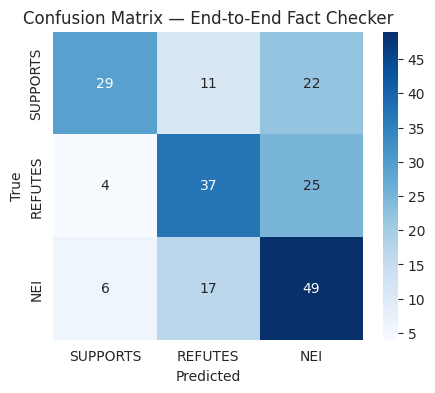

In [37]:
cm = confusion_matrix(y_true, y_pred, labels=["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["SUPPORTS", "REFUTES", "NEI"],
            yticklabels=["SUPPORTS", "REFUTES", "NEI"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — End-to-End Fact Checker")
plt.show()

In [38]:
tests = [
    (
        "Albert Einstein was a physicist.",
        "Albert Einstein was a German-born theoretical physicist."
    ),
    (
        "Albert Einstein is alive.",
        "Albert Einstein died in 1955."
    ),
    (
        "Albert Einstein played cricket.",
        "Albert Einstein won the Nobel Prize."
    )
]

for claim, evidence in tests:

    print("=" * 80)

    print(classify(claim, evidence))

{'prediction': 'SUPPORTS', 'confidence': 0.9970921277999878, 'probabilities': {'SUPPORTS': 0.9970921277999878, 'NOT ENOUGH INFO': 0.0023640249855816364, 'REFUTES': 0.0005438066436909139}}
{'prediction': 'REFUTES', 'confidence': 0.9996046423912048, 'probabilities': {'SUPPORTS': 8.93810429261066e-05, 'NOT ENOUGH INFO': 0.0003060502640437335, 'REFUTES': 0.9996046423912048}}
{'prediction': 'REFUTES', 'confidence': 0.5139553546905518, 'probabilities': {'SUPPORTS': 0.002630332252010703, 'NOT ENOUGH INFO': 0.48341432213783264, 'REFUTES': 0.5139553546905518}}


In [39]:
EVAL_SIZE = 200
eval_df = dev_df.sample(n=min(EVAL_SIZE, len(dev_df)), random_state=SEED).reset_index(drop=True)

y_true, raw_preds, raw_confs, latencies = [], [], [], []

for i, row in tqdm(eval_df.iterrows(), total=len(eval_df)):
    claim = row["claim_clean"]
    t0 = time.time()
    try:
        result = fact_check(claim)
    except Exception as e:
        print(f"Skipped claim {i}: {e}")
        continue
    t1 = time.time()

    y_true.append(row["label"])
    raw_preds.append(result["raw_label"])
    raw_confs.append(result["raw_confidence"])
    latencies.append(t1 - t0)

100%|██████████| 200/200 [11:44<00:00,  3.52s/it]


,threshold,accuracy,macro_f1
0,0.35,0.575,0.573961
1,0.40,0.575,0.573961
2,0.45,0.575,0.574629
3,0.50,0.575,0.574629
4,0.55,0.580,0.578947
5,0.60,0.575,0.574159
6,0.65,0.565,0.563746
7,0.70,0.565,0.561996
8,0.75,0.560,0.557116
9,0.80,0.550,0.547212


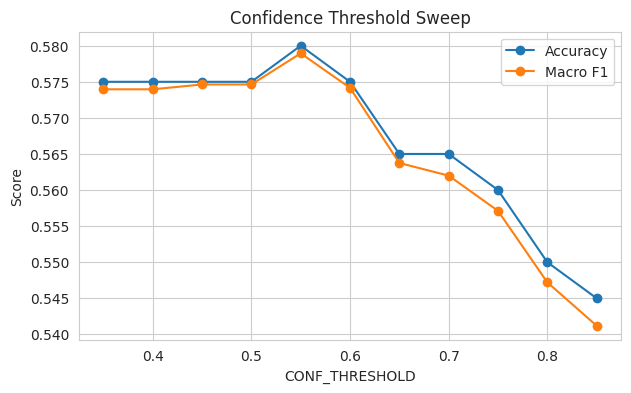

Best threshold by macro F1: 0.55 -> 0.579


In [40]:
from sklearn.metrics import accuracy_score, f1_score

def apply_conf_gate(raw_label, raw_conf, threshold):
    if raw_label in ("SUPPORTS", "REFUTES") and raw_conf < threshold:
        return "NOT ENOUGH INFO"
    return raw_label

thresholds = np.arange(0.35, 0.86, 0.05)
sweep_rows = []
for t in thresholds:
    gated = [apply_conf_gate(l, c, t) for l, c in zip(raw_preds, raw_confs)]
    sweep_rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_true, gated),
        "macro_f1": f1_score(y_true, gated, average="macro"),
    })

sweep_df = pd.DataFrame(sweep_rows)
display(sweep_df)

plt.figure(figsize=(7, 4))
plt.plot(sweep_df["threshold"], sweep_df["accuracy"], marker="o", label="Accuracy")
plt.plot(sweep_df["threshold"], sweep_df["macro_f1"], marker="o", label="Macro F1")
plt.xlabel("CONF_THRESHOLD"); plt.ylabel("Score"); plt.legend()
plt.title("Confidence Threshold Sweep")
plt.show()

best = sweep_df.loc[sweep_df["macro_f1"].idxmax()]
print(f"Best threshold by macro F1: {best['threshold']:.2f} -> {best['macro_f1']:.3f}")

## 14. Evidence Sentiment Signal (Bias-Analysis Prototype)

**Scope note:** the knowledge base here is Wikipedia — a single, broadly neutral encyclopedic source, not a set of competing news outlets. So this section does **not** measure "media bias across sources" as the project title implies; that requires ingesting multiple real news outlets with distinguishable editorial stances, which is future work. What's implemented here is a smaller, honest piece: a sentiment signal over the evidence actually retrieved for a claim, using VADER (rule-based, no API dependency). It's a working prototype for the bias-analysis component, not the finished module.

In [41]:
sentiment_analyzer = SentimentIntensityAnalyzer()

def sentiment_signal(evidence_list):
    scores = [sentiment_analyzer.polarity_scores(e["text"])["compound"] for e in evidence_list]
    return {
        "mean_sentiment": float(np.mean(scores)) if scores else 0.0,
        "per_evidence": scores,
    }

result = fact_check("Albert Einstein was a physicist")
sig = sentiment_signal(result["top_evidence"])
print("Verdict:", result["label"], f"(confidence {result['confidence']:.2f})")
print("Sentiment signal:", sig)

Verdict: SUPPORTS (confidence 1.00)
Sentiment signal: {'mean_sentiment': 0.5106, 'per_evidence': [0.5106]}


## 16. Error Analysis

In [42]:
from tqdm.auto import tqdm

errors = []

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df)):

    pred = fact_check(row["claim"])

    if pred["label"] != row["label"]:

        errors.append({
            "Claim": row["claim"],
            "True": row["label"],
            "Prediction": pred["label"],
            "Confidence": pred["confidence"],
            "Retrieved Title": pred["top_evidence"][0]["title"],
            "Retrieved Text": pred["top_evidence"][0]["text"]
        })

errors_df = pd.DataFrame(errors)
errors_df.to_csv("error_analysis.csv", index=False)

  0%|          | 0/200 [00:00<?, ?it/s]

## 15. Conclusion & Next Steps

**What this notebook delivers:**
- A hybrid (dense + BM25) retriever over ~486K Wikipedia passages, fully local, no external API dependency.
- A cross-encoder reranking stage between retrieval and verification.
- A FEVER-tuned NLI verifier with a confidence gate against low-confidence guesses.
- Retrieval-level (Recall@k) and end-to-end (accuracy/F1/confusion matrix/latency) evaluation, so every component's contribution is measurable rather than assumed.
- A scoped, honestly-labeled prototype for the evidence-sentiment / bias-analysis component.

**Real next steps, in priority order:**
1. Ingest actual multi-outlet news content (NewsAPI, RSS feeds, or similar) to make the bias-analysis module measure what the project title promises — cross-source comparison, not single-source sentiment.
2. Swap `IndexFlatIP` for `IndexHNSWFlat` (or an IVF index) if corpus size grows and exact search becomes a latency bottleneck.
3. Wrap `fact_check()` in a Streamlit or FastAPI app for interactive/real-time use.
4. Track retrieval and end-to-end metrics per FEVER label to see if errors concentrate in a specific class (e.g., NOT ENOUGH INFO is typically the hardest).

# Artifacts Saving

In [43]:
import pandas as pd

print("Collecting FEVER evidence titles...")

titles = set()

for df in [train_df, dev_df]:

    for ev in df["ev_titles"]:

        if isinstance(ev, set):
            titles.update(ev)

        elif isinstance(ev, list):
            titles.update(ev)

print("Unique FEVER titles:", len(titles))

wiki_df = wiki.to_pandas()

wiki_deploy = wiki_df[
    wiki_df["title"].isin(titles)
].reset_index(drop=True)

print(len(wiki_deploy))
print("Deployment corpus size:", len(wiki_deploy))

Unique FEVER titles: 14533
16657
Deployment corpus size: 16657


In [44]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm

embed_model = SentenceTransformer(EMBED_MODEL_NAME)

texts = (
    wiki_deploy["title"]
    + "\n\n"
    + wiki_deploy["text"]
).tolist()

embeddings = embed_model.encode(
    texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/131 [00:00<?, ?it/s]

(16657, 384)


In [45]:
import faiss

dimension = embeddings.shape[1]

faiss_index = faiss.IndexFlatIP(dimension)

faiss_index.add(
    embeddings.astype(np.float32)
)

print("Indexed:", faiss_index.ntotal)

Indexed: 16657


In [46]:
from rank_bm25 import BM25Okapi
import re

def bm25_tokenize(text):

    text = text.lower()

    text = re.sub(r"[^a-z0-9 ]", " ", text)

    return text.split()

tokenized_corpus = [
    bm25_tokenize(t)
    for t in texts
]

bm25 = BM25Okapi(tokenized_corpus)

print("BM25 built.")

BM25 built.


In [47]:
import os
import json
import faiss
import joblib

DEPLOY_DIR = "/kaggle/working/deployment_artifacts"

os.makedirs(DEPLOY_DIR, exist_ok=True)

# Wikipedia corpus
wiki_deploy.to_parquet(
    f"{DEPLOY_DIR}/wiki_corpus.parquet"
)

# FAISS index
faiss.write_index(
    faiss_index,
    f"{DEPLOY_DIR}/faiss.index"
)

# BM25 tokens
with open(
    f"{DEPLOY_DIR}/bm25_tokens.json",
    "w"
) as f:

    json.dump(
        tokenized_corpus,
        f
    )

# Configuration
config = {

    "embed_model": EMBED_MODEL_NAME,

    "reranker_model": RERANKER_MODEL_NAME,

    "nli_model": NLI_MODEL_NAME,

    "dimension": embeddings.shape[1],

    "num_documents": len(wiki_deploy)

}

with open(
    f"{DEPLOY_DIR}/config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [48]:
import shutil

zip_path = shutil.make_archive(
    "/kaggle/working/deployment_artifacts",
    "zip",
    DEPLOY_DIR
)

print(zip_path)

/kaggle/working/deployment_artifacts.zip
